# Multi-Label Classification of Dutch Election Political Manifestos

This notebook analyzes Dutch political manifestos (1986–1998) using multi-label classification to assign thematic codes to paragraphs.  

The study addresses four main research questions (RQs) using a fixed stratified train/dev/test split and consistent evaluation metrics (Precision, Recall, micro-F1 and macro-F1).

## Research Questions

**RQ1 – Classical Model Comparison**  
Compare different classical (non-transformer) text classification approaches across multiple text representations to identify the strongest baseline for multi-label theme prediction on manifesto paragraphs.

**RQ2 – Sparse vs Dense Feature Representations**  
Evaluate whether dense sentence embeddings (via multilingual SentenceTransformer) outperform sparse TF-IDF features when using the same best classifier pipeline from RQ1.

**RQ3 – Transformer vs Classical Baseline**  
Evaluate a Dutch transformer model (RobBERT-2023 with Focal Loss) against the best classifier pipeline from RQ1 on the same fixed test set.

**RQ4 – Effect of Label Frequency (Long-Tail Problem)**  
Examine how performance changes when rare labels are progressively removed using minimum global frequency cutoffs (5, 25, 50, 75, 100 occurrences).  
Both the best classifier pipeline and the transformer are re-evaluated on the filtered label sets.  

# 1. Setup – Mount Drive and Install Dependencies

This cell mounts Google Drive to access the manifesto XML files and installs the required Python packages

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Install required packages quietly
!pip -q install iterative-stratification sentence-transformers transformers spacy
!python -m spacy download nl_core_news_sm -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 65.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('nl_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# 2. Imports and Configuration

This cell imports all necessary libraries and defines global configuration parameters used throughout the notebook

In [11]:
# Imports and Configuration

import os
import re
import glob
import xml.etree.ElementTree as ET
import random
import numpy as np
import pandas as pd
import torch.nn.functional as F
import spacy
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, precision_score, recall_score

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sentence_transformers import SentenceTransformer

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, set_seed

# Configuration
RANDOM_SEED = 42
set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = "/content/drive/MyDrive/Input/Political_election_manifestos"
XML_FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.xml")))

TFIDF_MAX_FEATURES = 5000
TFIDF_NGRAM_RANGE = (1, 2)

EMBED_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
BERT_MODEL_NAME = "DTAI-KULeuven/robbert-2023-dutch-base"

MAX_LEN = 256
BERT_EPOCHS = 3
BERT_TRAIN_BATCH = 8
BERT_EVAL_BATCH = 8

LABEL_FREQ_CUTOFFS = [5, 25, 50, 75, 100]
MIN_TRAIN_POS = 2

# 3. Data Verification

This cell verifies that the data directory is accessible and contains XML files.

In [3]:
# Verify data directory and XML files
print("Data directory:", DATA_DIR)
print("Number of XML files found:", len(XML_FILES))

if len(XML_FILES) == 0:
    raise ValueError("No XML files found. Please check the directory path and file extensions.")

Data directory: /content/drive/MyDrive/Input/Political_election_manifestos
Number of XML files found: 3


# 4. Data Preprocessing Functions

This section defines core functions for loading, parsing, and preparing the manifesto data for multi-label classification.  
The functions handle:
- XML parsing into text + theme lists
- Conversion to feature (X) and label (Y) matrices
- Stratified splitting into train/validation/test sets
- Evaluation metrics (micro-F1 and macro-F1)
- Filtering untrainable labels
- Creation of classical model instances

In [4]:
def extract_year_from_filename(fp):
    """
    Extract year from filename
    """
    match = re.search(r'_(\d{4})\.', os.path.basename(fp))
    return int(match.group(1)) if match else None


def parse_manifesto_xml(file_paths):
    """
    Parse manifesto XML files into a DataFrame with text, themes, and year.
    Extracts text from <p> elements and collects theme IDs from <theme> tags.
    """
    rows = []
    for fp in file_paths:
        year = extract_year_from_filename(fp)
        if not os.path.exists(fp):
            raise FileNotFoundError(f"File not found: {fp}")

        try:
            tree = ET.parse(fp)
            root = tree.getroot()

            for p in root.iter("p"):
                themes = [t.get("id") for t in p.findall(".//theme") if t.get("id")]
                if not themes:
                    continue

                text = "".join(p.itertext()).strip().lower()
                if len(text) < 10:
                    continue

                rows.append({"text": text, "themes": themes, "year": year})

        except Exception as e:
            print(f"Skipping {os.path.basename(fp)} due to parse error: {e}")

    return pd.DataFrame(rows)


def build_xy_full(df):
    """
    Convert parsed DataFrame into features (X) and multi-label target matrix (Y).
    """
    X = df["text"].astype(str).reset_index(drop=True)
    themes_list = df["themes"].tolist()

    mlb = MultiLabelBinarizer()
    Y = pd.DataFrame(mlb.fit_transform(themes_list), columns=mlb.classes_)
    return X, Y


def multilabel_stratified_split_indices(X, Y, test_size=0.15, validation_size=0.15, seed=42):
    """
    Perform a fixed two-stage stratified split for multi-label data:
    - First split: train vs (validation + test)
    - Second split: validation vs test
    Returns indices for train, validation, and test sets.
    """
    msss1 = MultilabelStratifiedShuffleSplit(
        n_splits=1, test_size=(test_size + validation_size), random_state=seed
    )
    train_idx, temp_idx = next(msss1.split(X, Y))

    X_temp = X.iloc[temp_idx].reset_index(drop=True)
    Y_temp = Y.iloc[temp_idx].reset_index(drop=True)

    test_within_temp = test_size / (test_size + validation_size)
    msss2 = MultilabelStratifiedShuffleSplit(
        n_splits=1, test_size=test_within_temp, random_state=seed
    )
    validation_rel_idx, test_rel_idx = next(msss2.split(X_temp, Y_temp))

    validation_idx = temp_idx[validation_rel_idx]
    test_idx = temp_idx[test_rel_idx]
    return train_idx, validation_idx, test_idx


def eval_multilabel(y_true, y_pred):
    """
    Compute micro-F1 and macro-F1 scores for multi-label predictions.
    """
    return {
        "micro_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "micro_recall":    recall_score(y_true, y_pred, average="micro", zero_division=0),
        "micro_f1":        f1_score(y_true, y_pred, average="micro", zero_division=0),

        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1":        f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def drop_untrainable_labels(Y_train, Y_validation, Y_test, min_train_pos=2):
    """
    Remove label columns with fewer than min_train_pos positive examples in the training set.
    This prevents training instability in one-vs-rest classifiers.
    """
    train_pos = Y_train.sum(axis=0)
    keep_cols = train_pos[train_pos >= min_train_pos].index.tolist()

    return (
        Y_train[keep_cols],
        Y_validation[keep_cols],
        Y_test[keep_cols],
        keep_cols
    )


def make_classical_models(seed=42):
    """
    Return a dictionary of classical one-vs-rest classifiers for RQ1 comparison.
    """
    return {
        "Naive Bayes": OneVsRestClassifier(MultinomialNB()),
        "Logistic Regression": OneVsRestClassifier(
            LogisticRegression(max_iter=3000, solver="liblinear", random_state=seed)
        ),
        "Logistic Regression (balanced)": OneVsRestClassifier(
            LogisticRegression(
                max_iter=3000, solver="liblinear", class_weight="balanced", random_state=seed
            )
        ),
        "Linear Support Vector Machine": OneVsRestClassifier(LinearSVC(random_state=seed)),
    }

# 5. Dataset Loading & Basic Statistics

This cell loads the manifesto XML files, parses paragraphs into text and themes,  
creates the feature (X) and multi-label target (Y) matrices, and displays key statistics.  
It also visualizes the frequency of the top 50 most common labels.

Table: Statistics on the input data


,Year,# Words,Vocabulary size,# No of Paragraphs,# Themes,Words/paragraph (std. dev.),"Themes/paragraph (min–max, std. dev.)"
0,Overall,802796,59567,2533,380,317 (246),"8.5 (1–68, 6.0)"
1,1986,289735,29759,783,214,370 (340),"10.6 (1–68, 8.1)"
2,1994,268284,29764,935,217,287 (185),"6.9 (1–39, 4.2)"
3,1998,244777,28617,815,218,300 (184),"8.4 (1–29, 4.7)"


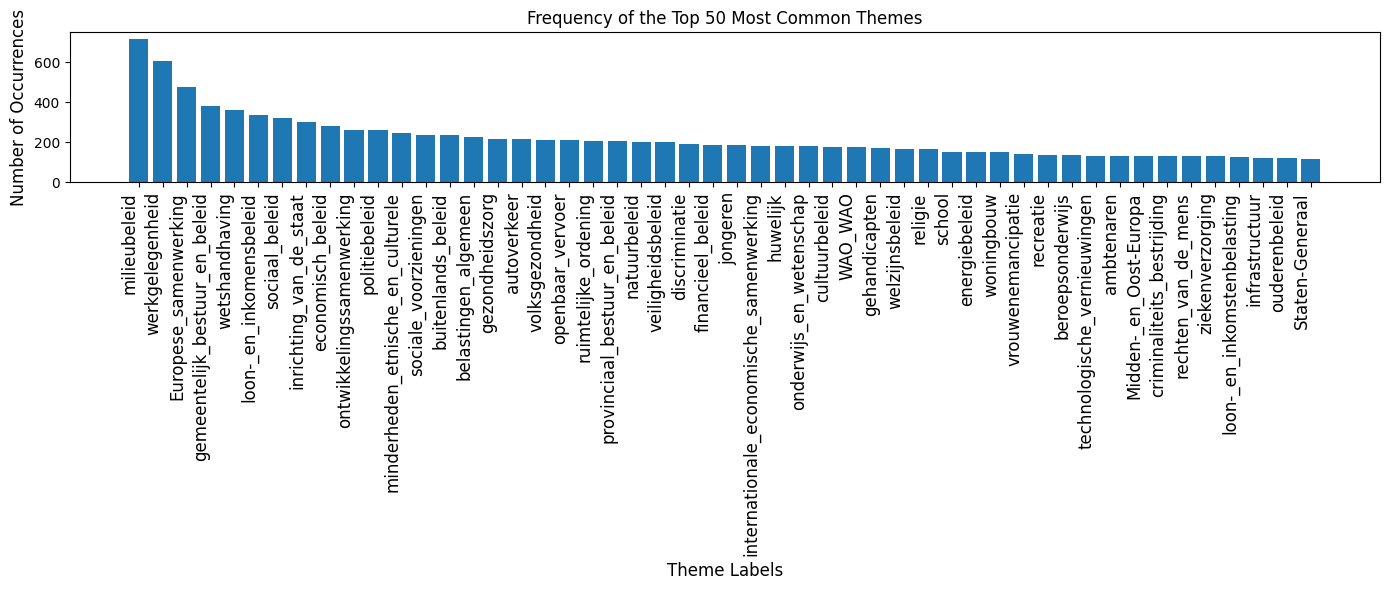

In [5]:
# Load and parse manifesto XML files
df = parse_manifesto_xml(XML_FILES)

# Build feature and target matrices
X_full, Y_full = build_xy_full(df)

# Word count
def wc(s):
    return len(str(s).split())

# Overall counts
n_paragraphs = len(df)
n_themes = Y_full.shape[1]

all_text = " ".join(X_full.astype(str).str.lower())
vocab_size = len(set(all_text.split()))

word_counts = X_full.apply(wc)
theme_counts = df["themes"].apply(len)

# Overall summary row
overall_row = pd.DataFrame([{
    "Year": "Overall",
    "# Words": int(word_counts.sum()),
    "Vocabulary size": int(vocab_size),
    "# No of Paragraphs": int(n_paragraphs),
    "# Themes": int(n_themes),
    "Words/paragraph (std. dev.)": f"{word_counts.mean():.0f} ({word_counts.std(ddof=1):.0f})",
    "Themes/paragraph (min–max, std. dev.)": f"{theme_counts.mean():.1f} ({theme_counts.min()}–{theme_counts.max()}, {theme_counts.std(ddof=1):.1f})",
}])

# Per-year stats
year_rows = []
for year, g in df.groupby("year"):
    wc_year = g["text"].apply(wc)
    themes_year = g["themes"].apply(len)

    vocab_year = len(set(" ".join(g["text"].astype(str).str.lower()).split()))
    year_unique_themes = len(set(t for lst in g["themes"] for t in lst))

    year_rows.append({
        "Year": int(year) if pd.notna(year) else year,
        "# Words": int(wc_year.sum()),
        "Vocabulary size": int(vocab_year),
        "# No of Paragraphs": int(len(g)),
        "# Themes": int(year_unique_themes),
        "Words/paragraph (std. dev.)": f"{wc_year.mean():.0f} ({wc_year.std(ddof=1):.0f})",
        "Themes/paragraph (min–max, std. dev.)": f"{themes_year.mean():.1f} ({themes_year.min()}–{themes_year.max()}, {themes_year.std(ddof=1):.1f})",
    })

year_df = pd.DataFrame(year_rows).sort_values("Year")
stats_df = pd.concat([overall_row, year_df], ignore_index=True)

print("Table: Statistics on the input data")
display(stats_df)

# Top 50 themes frequency plot
label_freq = Y_full.sum(axis=0).sort_values(ascending=False)
top_n = min(50, len(label_freq))
top_labels = label_freq.index[:top_n]
top_counts = label_freq.values[:top_n]

plt.figure(figsize=(14, 6))
plt.bar(range(top_n), top_counts)
plt.xticks(range(top_n), top_labels, rotation=90, ha='right', fontsize=12)
plt.xlabel("Theme Labels",fontsize=12)
plt.ylabel("Number of Occurrences",fontsize=12)
plt.title("Frequency of the Top 50 Most Common Themes",fontsize=12)
plt.tight_layout()
plt.show()


# 6. Fixed multi-label stratified split

This cell performs a fixed, stratified multi-label split of the dataset into train, validation, and test sets (15% each for validation and test).  
It then creates a base label set by removing labels with fewer than the minimum required positive examples in the training split.

In [6]:
# Perform stratified multi-label split
train_idx, validation_idx, test_idx = multilabel_stratified_split_indices(
    X_full, Y_full,
    test_size=0.15,
    validation_size=0.15,
    seed=RANDOM_SEED
)

# Create filtered splits
X_train = X_full.iloc[train_idx].reset_index(drop=True)
X_validation = X_full.iloc[validation_idx].reset_index(drop=True)
X_test = X_full.iloc[test_idx].reset_index(drop=True)

Y_train = Y_full.iloc[train_idx].reset_index(drop=True)
Y_validation = Y_full.iloc[validation_idx].reset_index(drop=True)
Y_test = Y_full.iloc[test_idx].reset_index(drop=True)

print(f"Split sizes — train/validation/test: {len(X_train)} / {len(X_validation)} / {len(X_test)}")

# Create base label set for RQ1/RQ2: remove labels with too few positives in train
Y_train_base, Y_validation_base, Y_test_base, base_keep_cols = drop_untrainable_labels(
    Y_train, Y_validation, Y_test,
    min_train_pos=MIN_TRAIN_POS
)

print(f"Trainable labels (base set): {len(base_keep_cols)} (dropped {Y_full.shape[1] - len(base_keep_cols)})")

Split sizes — train/validation/test: 1760 / 374 / 399
Trainable labels (base set): 376 (dropped 4)


# 7. Text Lemmatization

Text lemmatization with and without stopwords

In [7]:
# Load Dutch spaCy pipeline
nlp = spacy.load("nl_core_news_sm", disable=["ner", "parser", "textcat"])

def lemmatize_texts(text_series, remove_stopwords=False, batch_size=64):
    docs = nlp.pipe(text_series.astype(str).tolist(), batch_size=batch_size)
    out = []
    for doc in docs:
        toks = []
        for tok in doc:
            if not tok.is_alpha:
                continue
            if remove_stopwords and tok.is_stop:
                continue
            toks.append(tok.lemma_)
        out.append(" ".join(toks))
    return pd.Series(out)

# Lemmatized with stopwords
X_train_lemma_keep = lemmatize_texts(X_train, remove_stopwords=False)
X_validation_lemma_keep = lemmatize_texts(X_validation, remove_stopwords=False)
X_test_lemma_keep  = lemmatize_texts(X_test, remove_stopwords=False)

# Lemmatized without stopwords
X_train_lemma_nostop = lemmatize_texts(X_train, remove_stopwords=True)
X_validation_lemma_nostop = lemmatize_texts(X_validation, remove_stopwords=True)
X_test_lemma_nostop  = lemmatize_texts(X_test, remove_stopwords=True)

print("Text Lemmatization completed")

Text Lemmatization completed


# 8. RQ1 – Classical Model Comparison (Baseline)

**Research Question 1 (RQ1)**  
Compare different classical (non-transformer) text classification approaches across multiple text representations to identify the strongest baseline for multi-label theme prediction on manifesto paragraphs.

**Aim**  
Evaluate four classifiers (Naive Bayes, Logistic Regression, Logistic Regression (balanced),  
and Linear Support Vector Machine) using TF-IDF features extracted from the following text variants:
- Raw text
- Lemmatized text (keeping stopwords)
- Lemmatized text (removing stopwords)

We test both unigram and unigram+bigram settings.  
The best-performing combination (highest micro-F1, tie-breaker macro-F1) is selected as the classical baseline  
for downstream comparisons in RQ2, RQ3, and RQ4.

In [8]:
# ──────────────────────────────────────────────────────────────
# RQ1: Classical Model Comparison Across Text Representations
# ──────────────────────────────────────────────────────────────

def run_rq1_for_representation(rep_name, Xtr_text, Xte_text, ngram_range):
    tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=ngram_range)
    Xtr = tfidf.fit_transform(Xtr_text)
    Xte = tfidf.transform(Xte_text)

    rows = []
    classical_models = make_classical_models(seed=RANDOM_SEED)

    for model_name, clf in classical_models.items():
        clf.fit(Xtr, Y_train_base.values)
        y_pred = clf.predict(Xte)
        s = eval_multilabel(Y_test_base.values, y_pred)

        rows.append({
            "Representation": rep_name,
            "Model": model_name,
            "Precision": s["micro_precision"],
            "Recall": s["micro_recall"],
            "Micro-F1": s["micro_f1"],
            "Macro-F1": s["macro_f1"],
        })
    return rows


# Define all text representations and n-gram settings
rep_specs = [
    ("Unigrams", X_train, X_test, (1, 1)),
    ("Unigrams lemmatized", X_train_lemma_keep, X_test_lemma_keep, (1, 1)),
    ("Unigrams lemmatized (no stopwords)", X_train_lemma_nostop, X_test_lemma_nostop, (1, 1)),
    ("Unigrams + Bigrams", X_train, X_test, (1, 2)),
    ("Unigrams + Bigrams lemmatized", X_train_lemma_keep, X_test_lemma_keep, (1, 2)),
    ("Unigrams + Bigrams lemmatized (no stopwords)", X_train_lemma_nostop, X_test_lemma_nostop, (1, 2)),
]

# Run all combinations and collect results
rq1_rows = []
for rep_name, Xtr_rep, Xte_rep, ngr in rep_specs:
    print(f"Running: {rep_name}")
    rq1_rows.extend(run_rq1_for_representation(rep_name, Xtr_rep, Xte_rep, ngr))

rq1_df = pd.DataFrame(rq1_rows)

# Display full results table, sorted by Model and Representation
print("\nRQ1 Results – Classical Models across Text representations:")
display(rq1_df.sort_values(["Model", "Representation"]).round(4))

# Select the overall best pipeline (highest Micro-F1, tie-breaker Macro-F1)
best_row = rq1_df.sort_values(["Micro-F1", "Macro-F1"], ascending=False).iloc[0]
BEST_REPRESENTATION = best_row["Representation"]
best_model_name = best_row["Model"]

print(f"\nBest classical pipeline overall: {best_model_name} under [{BEST_REPRESENTATION}]")

# Refit the best pipeline for downstream consistency (RQ2, RQ3, RQ4)
rep_map = {
    name: (Xtr, Xte, ngr) for name, Xtr, Xte, ngr in rep_specs
}
X_train_best_text, X_test_best_text, best_ngram_range = rep_map[BEST_REPRESENTATION]

tfidf_best = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=best_ngram_range)
X_train_tfidf_best = tfidf_best.fit_transform(X_train_best_text)
X_test_tfidf_best = tfidf_best.transform(X_test_best_text)

best_tfidf_model = make_classical_models(seed=RANDOM_SEED)[best_model_name]
best_tfidf_model.fit(X_train_tfidf_best, Y_train_base.values)

y_pred_best_tfidf = best_tfidf_model.predict(X_test_tfidf_best)
rq1_best_scores = eval_multilabel(Y_test_base.values, y_pred_best_tfidf)

print("\nBest classical baseline – Test metrics:")
print(
    f"Precision={rq1_best_scores['micro_precision']:.3f} | "
    f"Recall={rq1_best_scores['micro_recall']:.3f} | "
    f"Micro-F1={rq1_best_scores['micro_f1']:.3f} | "
    f"Macro-F1={rq1_best_scores['macro_f1']:.3f}"
)


Running: Unigrams
Running: Unigrams lemmatized
Running: Unigrams lemmatized (no stopwords)
Running: Unigrams + Bigrams
Running: Unigrams + Bigrams lemmatized
Running: Unigrams + Bigrams lemmatized (no stopwords)

RQ1 Results – Classical Models across Text representations:


,Representation,Model,Precision,Recall,Micro-F1,Macro-F1
3,Unigrams,Linear Support Vector Machine,0.8053,0.2208,0.3466,0.1279
15,Unigrams + Bigrams,Linear Support Vector Machine,0.7934,0.2117,0.3343,0.1134
19,Unigrams + Bigrams lemmatized,Linear Support Vector Machine,0.7885,0.2088,0.3302,0.1117
23,Unigrams + Bigrams lemmatized (no stopwords),Linear Support Vector Machine,0.7896,0.2543,0.3846,0.1609
7,Unigrams lemmatized,Linear Support Vector Machine,0.7960,0.2220,0.3472,0.1264
11,Unigrams lemmatized (no stopwords),Linear Support Vector Machine,0.7817,0.2499,0.3787,0.1548
1,Unigrams,Logistic Regression,0.9078,0.0578,0.1086,0.0148
13,Unigrams + Bigrams,Logistic Regression,0.8925,0.0560,0.1054,0.0152
17,Unigrams + Bigrams lemmatized,Logistic Regression,0.9009,0.0560,0.1055,0.0148
21,Unigrams + Bigrams lemmatized (no stopwords),Logistic Regression,0.8984,0.0830,0.1519,0.0278



Best classical pipeline overall: Logistic Regression (balanced) under [Unigrams + Bigrams lemmatized (no stopwords)]

Best classical baseline – Test metrics:
Precision=0.459 | Recall=0.569 | Micro-F1=0.508 | Macro-F1=0.344


# 9. # RQ2 – Dense Sentence Embeddings vs Best TF-IDF Pipeline

This section compares the best TF-IDF pipeline from RQ1 (selected representation + best classifier)  
against the same classifier trained on dense sentence embeddings (SentenceTransformer).


**Aim**
Determine if pre-trained dense embeddings capture semantic relationships better than traditional TF-IDF keyword matching when predicting multiple themes in manifesto paragraphs.

In [9]:
# ──────────────────────────────────────────────────────────────
# RQ2: Dense Sentence Embeddings vs Best TF-IDF Pipeline
# ──────────────────────────────────────────────────────────────

rq2_results = {}

# Best TF-IDF pipeline from RQ1
print("Evaluating best TF-IDF pipeline")
rq2_results["TF-IDF (best pipeline)"] = rq1_best_scores

# Dense embeddings (using raw text )
print("Generating sentence embeddings from raw text")
embedder = SentenceTransformer(EMBED_MODEL_NAME)

X_train_emb = embedder.encode(X_train.tolist(), show_progress_bar=True)
X_test_emb  = embedder.encode(X_test.tolist(), show_progress_bar=True)

# Use the same best classifier type and parameters as RQ1
print(f"Training best classifier ({best_model_name}) on dense embeddings")

best_base_estimator = best_tfidf_model.estimator
best_clf_class = type(best_base_estimator)
best_clf_params = best_base_estimator.get_params()

best_clf = OneVsRestClassifier(best_clf_class(**best_clf_params))
best_clf.fit(X_train_emb, Y_train_base.values)

y_pred_dense = best_clf.predict(X_test_emb)
rq2_results["Dense Embedding"] = eval_multilabel(Y_test_base.values, y_pred_dense)

# RQ2 Results
print(f"\nRQ2 – Best TF-IDF pipeline vs Dense embeddings (using {best_model_name}):")
print(f"{'Method':<28} | {'Precision':>8} | {'Recall':>8} | {'Micro-F1':>8} | {'Macro-F1':>8}")
print("-" * 90)
for method, scores in rq2_results.items():
    print(
        f"{method:<28} | "
        f"{scores['micro_precision']:>8.3f} | {scores['micro_recall']:>8.3f} | "
        f"{scores['micro_f1']:>8.3f} | {scores['macro_f1']:>8.3f}"
    )

Evaluating best TF-IDF pipeline
Generating sentence embeddings from raw text


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Training best classifier (Logistic Regression (balanced)) on dense embeddings

RQ2 – Best TF-IDF pipeline vs Dense embeddings (using Logistic Regression (balanced)):
Method                       | Precision |   Recall | Micro-F1 | Macro-F1
------------------------------------------------------------------------------------------
TF-IDF (best pipeline)       |    0.459 |    0.569 |    0.508 |    0.344
Dense Embedding              |    0.178 |    0.603 |    0.275 |    0.190


# 10. RQ3 – Transformer-Based Classification

This section evaluates the full transformer approach (RoBERT-2023 fine-tuned with Focal Loss)  
and compares it against the best classical results from RQ1 (TF-IDF) and RQ2 (dense embeddings).

**Key settings**  
- Model: DTAI-KULeuven/robbert-2023-dutch-base
- Loss function: Focal Loss (γ=2.0, α=0.25)  
- Maximum sequence length: 512 tokens (to accommodate longer manifesto paragraphs)  
- Training: 10 epochs
- Threshold tuning: Performed on the validation set to optimize macro-F1  

In [13]:
# ──────────────────────────────────────────────────────────────
# RQ3: Transformer (RoBERT-2023) with Focal Loss vs Best Classical Baseline
# ──────────────────────────────────────────────────────────────

MAX_LEN = 512

class ManifestoDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        y = self.labels.iloc[idx].values.astype(np.float32)

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(y, dtype=torch.float32)
        }

# Helper functions
def sigmoid_np(logits):
    return torch.sigmoid(torch.tensor(logits)).numpy()

def threshold_preds(probs, threshold):
    return (probs >= threshold).astype(int)

def pick_best_threshold(probs, y_true):
    best_threshold = 0.5
    best_macro = -1.0
    for t in np.arange(0.01, 0.91, 0.025):
        pred = threshold_preds(probs, t)
        macro = f1_score(y_true, pred, average="macro", zero_division=0)
        if macro > best_macro:
            best_macro = macro
            best_threshold = t
    return best_threshold

# Training and evaluation function
def train_eval_bert_focal(
    X_train, Y_train, X_validation, Y_validation, X_test, Y_test,
    out_dir, model_name
):
    os.makedirs(out_dir, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=Y_train.shape[1],
        problem_type="multi_label_classification"
    )

    train_dataset = ManifestoDataset(X_train, Y_train, tokenizer, max_len=MAX_LEN)
    validation_dataset = ManifestoDataset(X_validation, Y_validation, tokenizer, max_len=MAX_LEN)
    test_dataset = ManifestoDataset(X_test, Y_test, tokenizer, max_len=MAX_LEN)

    training_args = TrainingArguments(
        output_dir=out_dir,
        num_train_epochs=10,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        lr_scheduler_type="cosine",
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=RANDOM_SEED
    )

    class FocalLoss(torch.nn.Module):
        def __init__(self, gamma=2.0, alpha=0.25, reduction='mean'):
            super().__init__()
            self.gamma = gamma
            self.alpha = alpha
            self.reduction = reduction

        def forward(self, logits, targets):
            bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
            pt = torch.exp(-bce_loss)
            focal_loss = (1 - pt) ** self.gamma * bce_loss
            if self.alpha is not None:
                focal_loss = self.alpha * focal_loss
            if self.reduction == 'mean':
                return focal_loss.mean()
            return focal_loss.sum()

    class FocalTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            loss_fct = FocalLoss(gamma=2.0, alpha=0.25)
            loss = loss_fct(outputs.logits, labels)
            return (loss, outputs) if return_outputs else loss

    trainer = FocalTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=validation_dataset,
        tokenizer=tokenizer
    )

    trainer.train()

    # Threshold tuning on validation set
    validation_out = trainer.predict(validation_dataset)
    validation_probs = sigmoid_np(validation_out.predictions)
    best_threshold = pick_best_threshold(validation_probs, Y_validation.values)

    # Final evaluation on test set
    test_out = trainer.predict(test_dataset)
    test_probs = sigmoid_np(test_out.predictions)
    y_pred = threshold_preds(test_probs, best_threshold)

    scores = eval_multilabel(Y_test.values, y_pred)
    return scores, best_threshold

# Run Transformer Evaluation
print("Fine-tuning RoBERT-2023 with Focal Loss for RQ3")

bert_scores, bert_best_threshold = train_eval_bert_focal(
    X_train, Y_train_base,
    X_validation, Y_validation_base,
    X_test, Y_test_base,
    out_dir="./bert_rq3_focal",
    model_name=BERT_MODEL_NAME
)

# Results
print("\nRQ3 Result Table:")
print(f"{'Method':<50} | {'Precision':>10} | {'Recall':>10} | {'Micro-F1':>10} | {'Macro-F1':>10}")
print("-" * 95)

# Best from RQ1 (TF-IDF best pipeline)
tfidf_best = rq1_best_scores
print(
    f"TF-IDF (best pipeline) + {best_model_name:<35} | "
    f"{tfidf_best['micro_precision']:>10.3f} | "
    f"{tfidf_best['micro_recall']:>10.3f} | "
    f"{tfidf_best['micro_f1']:>10.3f} | "
    f"{tfidf_best['macro_f1']:>10.3f}"
)

# From RQ2 (Dense Embeddings, same classifier)
dense_best = rq2_results["Dense Embedding"]
print(
    f"Dense Embeddings + {best_model_name:<35} | "
    f"{dense_best['micro_precision']:>10.3f} | "
    f"{dense_best['micro_recall']:>10.3f} | "
    f"{dense_best['micro_f1']:>10.3f} | "
    f"{dense_best['macro_f1']:>10.3f}"
)

print(
    f"{'RoBERT-2023 (Focal Loss)':<50} | "
    f"{bert_scores['micro_precision']:>10.3f} | "
    f"{bert_scores['micro_recall']:>10.3f} | "
    f"{bert_scores['micro_f1']:>10.3f} | "
    f"{bert_scores['macro_f1']:>10.3f}"
)

Fine-tuning RoBERT-2023 with Focal Loss for RQ3


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DTAI-KULeuven/robbert-2023-dutch-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3081057529.py:114: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalTrainer.__init__`. Use `processing_class` instead.
  trainer = FocalTrainer(


Epoch,Training Loss,Validation Loss
1,0.024900,0.008185
2,0.007300,0.006811
3,0.006800,0.006599
4,0.006500,0.006056
5,0.005900,0.005682
6,0.005500,0.005449
7,0.005300,0.005301
8,0.005100,0.005216
9,0.005000,0.005172
10,0.005000,0.005169



RQ3 Result Table:
Method                                             |  Precision |     Recall |   Micro-F1 |   Macro-F1
-----------------------------------------------------------------------------------------------
TF-IDF (best pipeline) + Logistic Regression (balanced)      |      0.459 |      0.569 |      0.508 |      0.344
Dense Embeddings + Logistic Regression (balanced)      |      0.178 |      0.603 |      0.275 |      0.190
RoBERT-2023 (Focal Loss)                           |      0.202 |      0.666 |      0.310 |      0.162


# 11. RQ4 – Effect of Label Frequency Cutoff (Long-Tail Analysis)

This section investigates how classification performance changes when rare labels are progressively removed  
using minimum global frequency cutoffs (5, 25, 50, 75, 100 occurrences).  

We compare two models on the filtered data for each cutoff:
- Baseline: Best classical pipeline from RQ1
- Transformer: RoBERT-2023 fine-tuned with Focal Loss (using raw text)

Both models are trained from scratch for each cutoff to observe the impact of reducing long-tail imbalance.

Cutoff ≥ 5
Training RoBERT-2023 (Focal Loss)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DTAI-KULeuven/robbert-2023-dutch-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3081057529.py:114: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalTrainer.__init__`. Use `processing_class` instead.
  trainer = FocalTrainer(


Epoch,Training Loss,Validation Loss
1,0.024500,0.008457
2,0.007600,0.007206
3,0.007100,0.006621
4,0.006500,0.006122
5,0.006000,0.005804
6,0.005600,0.005586
7,0.005400,0.005455
8,0.005200,0.005368
9,0.005100,0.005345
10,0.005100,0.005337


Cutoff ≥ 25
Training RoBERT-2023 (Focal Loss)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DTAI-KULeuven/robbert-2023-dutch-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3081057529.py:114: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalTrainer.__init__`. Use `processing_class` instead.
  trainer = FocalTrainer(


...

Cutoff ≥ 100
Training RoBERT-2023 (Focal Loss)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DTAI-KULeuven/robbert-2023-dutch-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3081057529.py:114: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalTrainer.__init__`. Use `processing_class` instead.
  trainer = FocalTrainer(


Epoch,Training Loss,Validation Loss
1,0.026000,0.018425
2,0.016200,0.014209
3,0.013400,0.013003
4,0.011700,0.012088
5,0.010300,0.011483
6,0.009300,0.011126
7,0.008500,0.010780
8,0.008100,0.010840
9,0.007800,0.010755
10,0.007700,0.010751


RQ4 Results – Performance by minimum label frequency cutoff:


,cutoff,n_labels,train_samples,test_samples,representation,classical_precision,classical_recall,classical_micro_f1,classical_macro_f1,bert_precision,bert_recall,bert_micro_f1,bert_macro_f1
0,5,354,1759,399,Unigrams + Bigrams lemmatized (no stopwords),0.4603,0.5702,0.5094,0.3598,0.2702,0.5891,0.3705,0.1770
1,25,202,1751,397,Unigrams + Bigrams lemmatized (no stopwords),0.4720,0.6047,0.5302,0.4716,0.3345,0.6755,0.4475,0.3596
2,50,130,1725,392,Unigrams + Bigrams lemmatized (no stopwords),0.4878,0.6209,0.5464,0.4969,0.4141,0.6739,0.5130,0.4470
3,75,81,1699,389,Unigrams + Bigrams lemmatized (no stopwords),0.5123,0.6440,0.5707,0.5302,0.5076,0.6791,0.5810,0.5331
4,100,57,1664,384,Unigrams + Bigrams lemmatized (no stopwords),0.5354,0.6647,0.5931,0.5619,0.6034,0.6663,0.6333,0.5979


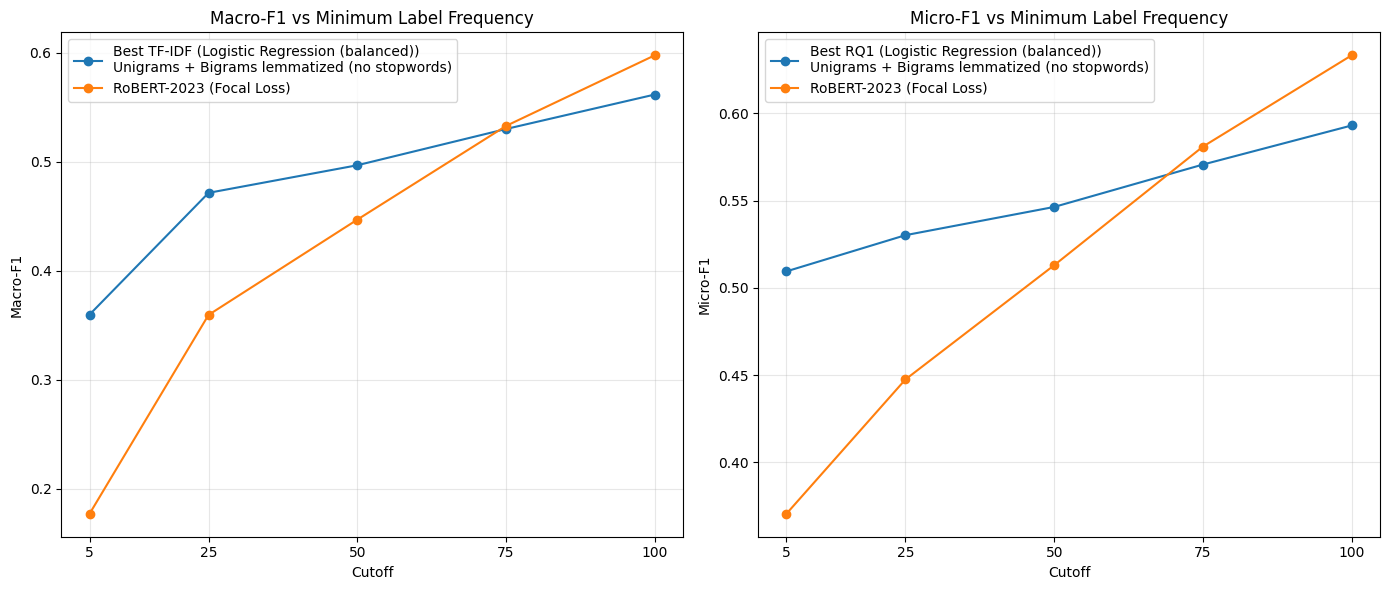

In [14]:
# ──────────────────────────────────────────────────────────────
# RQ4 Long-tail analysis – Effect of removing rare labels
# ──────────────────────────────────────────────────────────────

def pick_text_view(rep_name, X_raw, X_lemma_keep, X_lemma_nostop):
    if "lemmatized (no stopwords)" in rep_name:
        return X_lemma_nostop
    elif "lemmatized" in rep_name:
        return X_lemma_keep
    else:
        return X_raw

label_freq_global = Y_full.sum(axis=0)
rq4_rows = []

for cutoff in LABEL_FREQ_CUTOFFS:
    print(f"Cutoff ≥ {cutoff}")

    keep_cols = label_freq_global[label_freq_global >= cutoff].index.tolist()
    if not keep_cols:
        print("No labels remain → skipping")
        continue

    Y_train_filtered = Y_train[keep_cols].copy()
    Y_validation_filtered = Y_validation[keep_cols].copy()
    Y_test_filtered = Y_test[keep_cols].copy()

    Y_train_filtered, Y_validation_filtered, Y_test_filtered, keep_cols = drop_untrainable_labels(
        Y_train_filtered, Y_validation_filtered, Y_test_filtered, min_train_pos=MIN_TRAIN_POS
    )
    if not keep_cols:
        print("All remaining labels untrainable → skipping")
        continue

    keep_train = Y_train_filtered.sum(axis=1) > 0
    keep_validation = Y_validation_filtered.sum(axis=1) > 0
    keep_test = Y_test_filtered.sum(axis=1) > 0

    # Raw text (for BERT)
    X_train_raw_f = X_train[keep_train].reset_index(drop=True)
    X_validation_raw_f = X_validation[keep_validation].reset_index(drop=True)
    X_test_raw_f = X_test[keep_test].reset_index(drop=True)

    # Pick correct text view for classical baseline (based on RQ1 best)
    X_train_text_f = pick_text_view(BEST_REPRESENTATION, X_train_raw_f,
                                    X_train_lemma_keep[keep_train],
                                    X_train_lemma_nostop[keep_train])
    X_validation_text_f = pick_text_view(BEST_REPRESENTATION, X_validation_raw_f,
                                         X_validation_lemma_keep[keep_validation],
                                         X_validation_lemma_nostop[keep_validation])
    X_test_text_f = pick_text_view(BEST_REPRESENTATION, X_test_raw_f,
                                   X_test_lemma_keep[keep_test],
                                   X_test_lemma_nostop[keep_test])

    Y_train_f = Y_train_filtered[keep_train].reset_index(drop=True)
    Y_validation_f = Y_validation_filtered[keep_validation].reset_index(drop=True)
    Y_test_f = Y_test_filtered[keep_test].reset_index(drop=True)

    # Classical baseline: Re-train best RQ1 pipeline on filtered data
    tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=best_ngram_range)
    X_train_tf = tfidf.fit_transform(X_train_text_f)
    X_test_tf = tfidf.transform(X_test_text_f)

    best_clf_class = type(best_tfidf_model.estimator)
    best_clf = OneVsRestClassifier(best_clf_class(**best_tfidf_model.estimator.get_params()))

    best_clf.fit(X_train_tf, Y_train_f)
    pred_best = best_clf.predict(X_test_tf)
    best_classical_scores = eval_multilabel(Y_test_f.values, pred_best)

    row = {
        "cutoff": cutoff,
        "n_labels": len(keep_cols),
        "train_samples": len(X_train_text_f),
        "test_samples": len(X_test_text_f),
        "representation": BEST_REPRESENTATION,
        "classical_precision": best_classical_scores["micro_precision"],
        "classical_recall": best_classical_scores["micro_recall"],
        "classical_micro_f1": best_classical_scores["micro_f1"],
        "classical_macro_f1": best_classical_scores["macro_f1"],
        "bert_precision": np.nan,
        "bert_recall": np.nan,
        "bert_micro_f1": np.nan,
        "bert_macro_f1": np.nan,
    }

    # BERT with Focal Loss (always on raw text)
    print("Training RoBERT-2023 (Focal Loss)")
    bert_scores, _ = train_eval_bert_focal(
        X_train_raw_f, Y_train_f,
        X_validation_raw_f, Y_validation_f,
        X_test_raw_f, Y_test_f,
        out_dir=f"./rq4_bert_focal_cutoff_{cutoff}",
        model_name=BERT_MODEL_NAME
    )

    row.update({
        "bert_precision": bert_scores["micro_precision"],
        "bert_recall": bert_scores["micro_recall"],
        "bert_micro_f1": bert_scores["micro_f1"],
        "bert_macro_f1": bert_scores["macro_f1"],
    })

    rq4_rows.append(row)

# Results
rq4_df = pd.DataFrame(rq4_rows)

print("RQ4 Results – Performance by minimum label frequency cutoff:")
display(rq4_df.round(4))

# Dual plot: Macro-F1 (left) and Micro-F1 (right)
if not rq4_df.empty:
    fig = plt.figure(figsize=(14, 6))
    gs = GridSpec(1, 2, width_ratios=[1, 1])

    # Left: Macro-F1
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(rq4_df["cutoff"], rq4_df["classical_macro_f1"], marker="o",
             label=f"Best TF-IDF ({best_model_name})\n{BEST_REPRESENTATION}")
    ax1.plot(rq4_df["cutoff"], rq4_df["bert_macro_f1"], marker="o", label="RoBERT-2023 (Focal Loss)")
    ax1.set_title("Macro-F1 vs Minimum Label Frequency")
    ax1.set_xlabel("Cutoff")
    ax1.set_ylabel("Macro-F1")
    ax1.set_xticks(LABEL_FREQ_CUTOFFS)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Right: Micro-F1
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(rq4_df["cutoff"], rq4_df["classical_micro_f1"], marker="o",
             label=f"Best RQ1 ({best_model_name})\n{BEST_REPRESENTATION}")
    ax2.plot(rq4_df["cutoff"], rq4_df["bert_micro_f1"], marker="o", label="RoBERT-2023 (Focal Loss)")
    ax2.set_title("Micro-F1 vs Minimum Label Frequency")
    ax2.set_xlabel("Cutoff")
    ax2.set_ylabel("Micro-F1")
    ax2.set_xticks(LABEL_FREQ_CUTOFFS)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()
